## 1. What this notebook computes

The Rust Kohn-Sham solver of the repository finds the levels and orbitals of the
Kohn-Sham equations of dirac16complex by **shooting**, labels every level with an
integer (the **Pruefer label**), and makes the potentials self-consistent with
**Anderson mixing**. This notebook writes the same method in plain Python, step by
step, and reproduces numbers of the committed Revision record:

- the exact levels at $k = 0$ (formulas) and the solver's numerical levels;
- the order of accuracy of the integration (the error falls 16-fold when the step is
  halved);
- the slope $c = 1.9051482536$ of the brane band and its redshift along the
  deflating history;
- the self-consistent ground states of $N = 8$ particles for the four couplings
  $\pm\lambda_1$, $\pm\lambda_2$: energies, levels and even the residual of each
  iteration of the loop;
- an exact symmetry of these states: $E_{KS}(-\lambda) = -E_{KS}(+\lambda)$.

It draws six figures. It needs no Rust: the Python code is short enough to read in
full, and it is slower than the solver only by a factor of about a hundred.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 15e (The solver's method by hand: shooting, Pruefer count and Anderson mixing)
is the file `Revision/textbook/notebooks/15e_shooting_by_hand.ipynb` of the repository
Dirac_claude. It re-implements in plain Python the numerical method of the Rust Kohn-Sham
solver (fourth-order Runge-Kutta shooting in the hidden coordinate, the Pruefer angle
that labels every level, a safeguarded Newton root, the normalisation of the orbitals,
and the self-consistent loop with Anderson mixing), and uses it to reproduce the solver's
exact free spectra, its convergence order, the slope of the brane band and the
interacting ground states of N = 8 particles from the committed Revision record. It needs
a computer with Windows 11, macOS or Linux, an internet connection for the installation,
the program Git, and Python 3.12 or newer (the notebooks were built with Python 3.14.5)
with these packages at exactly these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0,
matplotlib 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0
and nbconvert 7.16.6. The notebook itself imports numpy and matplotlib; the other
packages run Jupyter, the program that shows and runs notebooks. It does not need Rust.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (about 130 MB; the folder then takes about 400
MB of disk space) into the folder Dirac_claude inside your home folder, create a private
Python environment in the folder dirac-book-env inside your home folder (a private
environment is a folder with its own copy of Python and of the packages, so that nothing
else on your computer is changed), activate it (from then on the commands `python` and
`jupyter` typed in this terminal are those of the environment, and the prompt starts with
(dirac-book-env)), and install the packages at the pinned versions (this downloads about
90 MB and takes a few minutes; the environment takes about 400 MB of disk space). If you
have done this step before, for this or for another notebook, skip it and go to Step 4;
to get the newest version of the repository, run `git pull` in the repository folder
after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 15e_shooting_by_hand.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 25 seconds on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 6. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 15e_shooting_by_hand.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
15e_shooting_by_hand.ipynb` (in the same folder, without running the cells again) to read
the printed lines and see the figures.

**Step 7. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:

- `Revision/textbook/figures/15e.captions.json`
- `Revision/textbook/figures/15e_1_phase_function.png`
- `Revision/textbook/figures/15e_2_orbitals.png`
- `Revision/textbook/figures/15e_3_rk4_convergence.png`
- `Revision/textbook/figures/15e_4_brane_band.png`
- `Revision/textbook/figures/15e_5_scf_mixing.png`
- `Revision/textbook/figures/15e_6_n8_potentials.png`

It changes no other file of the repository; running it headless or saving it in
JupyterLab also rewrites the notebook file itself. It does not use the internet while it
runs. The files it writes are the same files that are stored in the repository (on
another computer a figure may differ in a few bytes, which is harmless). To get the
stored versions back, run this command in the repository folder (it also undoes every
change you made yourself in the folder Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS every figure file of this notebook exists
    ALL 18 CHECKS PASSED (notebook 15e)

and the notebook must show 6 figures below the cells that draw them.

**Step 8. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/15e_shooting_by_hand.ipynb` inside the folder
  Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4 (or type `python -m jupyter` instead of `jupyter`).
- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 15e (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 15e (The solver's method by hand: shooting, Pruefer count and Anderson mixing)
# is the file Revision/textbook/notebooks/15e_shooting_by_hand.ipynb of the repository
# Dirac_claude. It re-implements in plain Python the numerical method of the Rust
# Kohn-Sham solver (fourth-order Runge-Kutta shooting in the hidden coordinate, the
# Pruefer angle that labels every level, a safeguarded Newton root, the normalisation of
# the orbitals, and the self-consistent loop with Anderson mixing), and uses it to
# reproduce the solver's exact free spectra, its convergence order, the slope of the
# brane band and the interacting ground states of N = 8 particles from the committed
# Revision record. It needs a computer with Windows 11, macOS or Linux, an internet
# connection for the installation, the program Git, and Python 3.12 or newer (the
# notebooks were built with Python 3.14.5) with these packages at exactly these versions:
# numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab 4.4.10, nbformat
# 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The notebook itself
# imports numpy and matplotlib; the other packages run Jupyter, the program that shows
# and runs notebooks. It does not need Rust.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (about 130 MB; the folder then takes about
# 400 MB of disk space) into the folder Dirac_claude inside your home folder, create a
# private Python environment in the folder dirac-book-env inside your home folder (a
# private environment is a folder with its own copy of Python and of the packages, so
# that nothing else on your computer is changed), activate it (from then on the commands
# python and jupyter typed in this terminal are those of the environment, and the prompt
# starts with (dirac-book-env)), and install the packages at the pinned versions (this
# downloads about 90 MB and takes a few minutes; the environment takes about 400 MB of
# disk space). If you have done this step before, for this or for another notebook, skip
# it and go to Step 4; to get the newest version of the repository, run git pull in the
# repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 15e_shooting_by_hand.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 25
# seconds on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 6. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 15e_shooting_by_hand.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 15e_shooting_by_hand.ipynb (in the same folder, without running the cells again) to
# read the printed lines and see the figures.
#
# STEP 7. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
#
# - Revision/textbook/figures/15e.captions.json
# - Revision/textbook/figures/15e_1_phase_function.png
# - Revision/textbook/figures/15e_2_orbitals.png
# - Revision/textbook/figures/15e_3_rk4_convergence.png
# - Revision/textbook/figures/15e_4_brane_band.png
# - Revision/textbook/figures/15e_5_scf_mixing.png
# - Revision/textbook/figures/15e_6_n8_potentials.png
#
# It changes no other file of the repository; running it headless or saving it in
# JupyterLab also rewrites the notebook file itself. It does not use the internet while
# it runs. The files it writes are the same files that are stored in the repository (on
# another computer a figure may differ in a few bytes, which is harmless). To get the
# stored versions back, run this command in the repository folder (it also undoes every
# change you made yourself in the folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS every figure file of this notebook exists
#     ALL 18 CHECKS PASSED (notebook 15e)
#
# and the notebook must show 6 figures below the cells that draw them.
#
# STEP 8. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/15e_shooting_by_hand.ipynb inside the folder
#   Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4 (or type python -m jupyter instead of jupyter).
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell

NOTEBOOK_ID = "15e"  # this notebook: chapter 15, example e


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 15e complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Orbital**: a one-particle wave function; here a pair of real functions $a(y)$,
  $b(y)$ of the hidden coordinate $y$.
- **Ordinary differential equation (ODE)**: an equation for functions of one
  variable that contains their derivatives. Given the values at one point (the
  **initial values**) it fixes the functions everywhere.
- **RK4** (the classical fourth-order Runge-Kutta method): a recipe that advances
  the solution of an ODE by one **step** $h$ using four evaluations of the
  derivatives; its error falls like $h^4$.
- **Shooting**: guess an energy $\varepsilon$, start the orbital at one end with
  the boundary condition of that end, integrate to the other end, and change
  $\varepsilon$ until the boundary condition there holds too.
- **Pruefer angle**: the angle $\theta$ of the point $(a, b)$ seen from the origin,
  $a = r\cos\theta$, $b = r\sin\theta$, followed continuously (it may grow beyond
  $2\pi$).
- **Phase function** $\Phi(\varepsilon)$: $j$ times the Pruefer angle at the brane.
  It increases strictly with $\varepsilon$.
- **Label** $l$: the whole number that says which crossing of $\Phi$ with the
  targets $l\pi$ (even parity) or $\pi/2 + l\pi$ (odd parity) a level is.
- **Root**: a value where a function is zero. **Newton's method** improves a guess
  $x$ to $x - F(x)/F'(x)$. A **bracket** is an interval known to contain the root;
  **bisection** halves it.
- **Normalisation**: multiplying an orbital by a number so that
  $\int_{-L}^{0} (a^2 + b^2)\,dy = 1$.
- **Simpson's rule**: $\int f\,dy \approx \tfrac{h}{6}[f_0 + 4 f_{1/2} + 2 f_1 +
  4 f_{3/2} + \dots + f_G]$ on the step ends and midpoints of $G$ steps.
- **Cubic Hermite interpolation**: the value in the middle of a step from the values
  and the derivatives at its two ends.
- **Self-consistency, residual, mixing**: the potentials made from the orbitals must
  equal the potentials that made the orbitals. The residual is the largest change
  in one iteration. **Linear mixing** moves a fraction $\beta$ of the way toward the
  new potential; **Anderson mixing** combines the last few iterations so that their
  residuals cancel as far as possible.

## 4. The physical and mathematical situation

The author's metric has 3-space $x_1, x_2, x_3$ (scale factor $e^{a_4}\sin^{1/6} z$),
the time $x_4$, three extra times $x_5, x_6, x_7$ that deflate exponentially (scale
factor $e^{-a_4}\sin^{1/6} z$) and the hidden direction $x_8$, with $z = 6 H x_8$.
In the hidden coordinate $y = \ln(\sin z)/(6H)$, from the tip $y = -L$ to the brane
$y = 0$, the Kohn-Sham equation of dirac16complex reduces exactly (Revision record
Revision/kohn_sham/ks-theory.json) to eight $2 \times 2$ blocks. With the orbital
written as $\chi = (a, i\,b)$, $a$ and $b$ real, a block of type $j = \pm 1$ at the
3-momentum $k$ is the real system

$$a' = M a - (\kappa k + j(\varepsilon - v))\,b, \qquad
b' = (j(\varepsilon - v) - \kappa k)\,a - M b, \qquad \kappa = e^{-Hy - a_{4,0}},$$

with the effective mass $M(y)$ and potential $v(y)$. Boundary conditions: at the tip
$b(-L) = 0$ (chosen); at the brane $b(0) = 0$ for even and $a(0) = 0$ for odd parity
(the Z2 mirror, ASSUMED).

**The Pruefer angle.** Write $a = r\cos\theta$, $b = r\sin\theta$. Then
$a b' - b a' = r^2 \theta'$. Inserting the system:

$$a b' - b a' = j(\varepsilon - v)(a^2 + b^2) - \kappa k (a^2 - b^2) - 2 M a b,$$

because the terms $-M a b$ (from $a b'$) and $-M a b$ (from $-b a'$) add, the terms
with $\kappa k$ give $-\kappa k a^2 + \kappa k b^2$, and the terms with
$j(\varepsilon - v)$ give $j(\varepsilon - v)(a^2 + b^2)$. Dividing by $r^2$ and
using $a^2 - b^2 = r^2\cos 2\theta$ and $2ab = r^2\sin 2\theta$:

$$\theta' = j(\varepsilon - v) - \kappa k \cos 2\theta - M \sin 2\theta .$$

At the tip $\theta(-L) = 0$ (because $b = 0$ there). The derivative of $\theta'$ with
respect to $\varepsilon$ is $j$, so $j\theta$ grows faster for a larger
$\varepsilon$: the **phase function** $\Phi(\varepsilon) = j\,\theta(0)$ increases
strictly with $\varepsilon$ (the solver's documentation gives the exact formula
$d\theta(0)/d\varepsilon = j\int r^2 dy / r(0)^2$). It also runs from $-\infty$ to
$+\infty$: for large $|\varepsilon|$ the term $j(\varepsilon - v)$ dominates
$\theta'$, so $\Phi(\varepsilon) \approx \varepsilon L$. Even parity, $b(0) = 0$, means
$\theta(0)$ is a whole multiple of $\pi$; odd parity, $a(0) = 0$, means
$\theta(0) = \pi/2 + $ a multiple of $\pi$. Because $\Phi$ increases strictly, each
target $l\pi$ (even) or $\pi/2 + l\pi$ (odd) is reached at exactly one energy: **every
level has its own whole number $l$, and no level can be missed** (the oscillation
theorem).

**Exact levels at $k = 0$** with constant $M = m$ and $v = 0$ (Revision record
ks-theory.json, boundaryConditions.exactK0Spectra): even parity: $\varepsilon = 0$
with the zero mode $(a, b) = (e^{My}, 0)$, and $\varepsilon = \pm\sqrt{M^2 +
(n\pi/L)^2}$, $n = 1, 2, \dots$; odd parity: $\varepsilon = \pm\sqrt{M^2 + p^2}$
with $\tan(pL) = -p/M$.

**The self-consistent problem for $N = 8$.** Eight particles fill the eight zero
modes at $k = 0$ (four orbitals for each $j$). Their proper densities are
$n = \sum w\,g\,f\,P\,(a^2 + b^2)$ and $S = \sum w\,g\,f\,P\,j\,2ab$ with
$P = e^{-6Hy}/\mathrm{Vol}_7$, $w = 1/2$, $g = 4$, $f = 1$; the potentials are
$M = m + \tfrac{15}{16}\lambda S$ and $v = -\tfrac{1}{16}\lambda n$; the energy is
$E_{KS} = \sum g f \varepsilon - 2\,\mathrm{Vol}_7 \int e^{6Hy} e_{int}\,dy$ with
$e_{int} = \lambda(\tfrac{15}{32}S^2 - \tfrac{1}{32}n^2)$. Units $H = m = 1$, $L = 3$,
$\Delta k = 0.25$, $\mathrm{Vol}_7 = (2\pi/\Delta k)^3$.

The history $a_4 = A H x_4$ is a PRESCRIBED BACKGROUND; the states are instantaneous
states at a slice $a_{4,0}$, which enters only through $\kappa$.

## 5. The grid

The solver integrates with $G = 900$ RK4 steps of length $h = L/G$ from $y = -L$ to
$y = 0$. Every RK4 step needs the potentials at its two ends and at its midpoint, so
the potentials live on the **fine grid** of the $2G + 1$ step ends and midpoints.
The next cell builds this grid exactly as the solver does: the coordinates $y_f$,
the factors $e^{-Hy}$ (for $\kappa$) and $e^{6Hy}$ (the proper volume), and the
Simpson weights. The check: Simpson's rule integrates $e^{y}$ from $-3$ to $0$ to
$1 - e^{-3}$ within $10^{-13}$.

In [2]:
import csv  # reads the tables (CSV files) of the Revision record
import math  # exp, sqrt, atan2, pi for single numbers

import numpy as np  # arrays of numbers

H, MASS, L = 1.0, 1.0, 3.0  # the units H = m = 1 and the tip cutoff L = 3
DK = 0.25  # the spacing of the 3-momenta
VOL7 = (2.0 * math.pi / DK) ** 3  # proper 7-volume per unit e^{6Hy} (v_t = 1)
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300",
           "#4a3aa7", "#e34948"]  # the colours of the figures, in a fixed order


def make_grid(steps):
    """The solver's grid for `steps` RK4 steps on [-L, 0] (a dictionary)."""
    points = 2 * steps + 1  # step ends and step midpoints
    y = [-L * ((points - 1 - f) / (points - 1)) for f in range(points)]
    half = 0.5 * L / steps  # the distance between two fine points
    weights = [(4.0 if f % 2 == 1 else 2.0) * half / 3.0 for f in range(points)]
    weights[0] = weights[-1] = half / 3.0  # Simpson: 1, 4, 2, 4, ..., 4, 1 (x h/6)
    return {"steps": steps, "h": L / steps, "points": points, "y": y,
            "ew": [math.exp(-H * v) for v in y], "e6": [math.exp(6 * H * v) for v in y],
            "simpson": np.array(weights)}


GRID = make_grid(900)  # the canonical grid of the solver
Y = np.array(GRID["y"])
E6 = np.array(GRID["e6"])
simpson_test = float(np.sum(GRID["simpson"] * np.exp(Y)))
say(f"fine grid: {GRID['points']} points, step h = {GRID['h']:.6f}")
report("Simpson integral of e^y from -3 to 0", f"{simpson_test:.15f}")
check(abs(simpson_test - (1.0 - math.exp(-3.0))) < 1e-13,
      "Simpson's rule on the fine grid integrates e^y exactly to 1e-13")

fine grid: 1801 points, step h = 0.003333
RESULT Simpson integral of e^y from -3 to 0 = 0.950212931632177
PASS Simpson's rule on the fine grid integrates e^y exactly to 1e-13


## 6. Shooting: one integration from the tip to the brane

The next cell is the heart of the method. `rhs` is the right-hand side $(a', b')$ of
the block equation. `shoot` starts at the tip with $(a, b) = (1, 0)$ (this satisfies
$b(-L) = 0$), makes $G$ RK4 steps to the brane, and follows the Pruefer angle: after
each step it computes the angle of the new point with `atan2` and adds the change of
angle (brought into $(-\pi, \pi]$) to $\theta$, so $\theta$ is followed continuously.
It also adds up $\int r^2\,dy$ (trapezoid rule) for the derivative
$d\Phi/d\varepsilon = \int r^2 dy / r(0)^2$, which Newton's method needs. When
asked (`store=True`) it keeps the values at the step ends. The potentials `mass`
and `pot` are lists of $M$ and $v$ on the fine grid.

In [3]:
def rhs(m_y, kk, je, a, b):
    """(a', b') of the block equation; kk = kappa k, je = j (eps - v)."""
    return m_y * a - (kk + je) * b, (je - kk) * a - m_y * b


def shoot(eps, k, j, a4, mass, pot, grid=GRID, store=False):
    """Integrate from the tip to the brane.  Returns (Phi, dPhi/deps, node values)."""
    h = grid["h"]
    kk = k * math.exp(-a4)  # k e^{-a4,0}; kappa k = kk e^{-Hy}
    coef = [(mass[f], kk * grid["ew"][f], j * (eps - pot[f]))
            for f in range(grid["points"])]
    a, b = 1.0, 0.0  # the tip condition b(-L) = 0
    theta, raw = 0.0, 0.0  # the followed angle and the last angle from atan2
    area, r2_prev = 0.0, 1.0  # integral of r^2 (trapezoid) and r^2 at the last node
    nodes = [(a, b)] if store else None
    for i in range(grid["steps"]):
        c0, c1, c2 = coef[2 * i], coef[2 * i + 1], coef[2 * i + 2]  # end, mid, end
        k1a, k1b = rhs(*c0, a, b)
        k2a, k2b = rhs(*c1, a + 0.5 * h * k1a, b + 0.5 * h * k1b)
        k3a, k3b = rhs(*c1, a + 0.5 * h * k2a, b + 0.5 * h * k2b)
        k4a, k4b = rhs(*c2, a + h * k3a, b + h * k3b)
        a += h / 6.0 * (k1a + 2.0 * k2a + 2.0 * k3a + k4a)
        b += h / 6.0 * (k1b + 2.0 * k2b + 2.0 * k3b + k4b)
        new = math.atan2(b, a)
        change = new - raw
        if change > math.pi:  # bring the change of angle into (-pi, pi]
            change -= 2.0 * math.pi
        elif change <= -math.pi:
            change += 2.0 * math.pi
        theta += change
        raw = new
        r2 = a * a + b * b
        area += 0.25 * h * (r2_prev + r2)  # trapezoid on the half steps of the solver
        r2_prev = r2
        if store:
            nodes.append((a, b))
    return j * theta, area / r2_prev, nodes


FREE_MASS = [MASS] * GRID["points"]  # M = m everywhere (no interaction)
FREE_POT = [0.0] * GRID["points"]  # v = 0 everywhere
phi_zero, _, _ = shoot(0.0, 0.0, 1, 0.0, FREE_MASS, FREE_POT)
report("Phi(0) for k = 0, j = +1 (the zero mode: b stays 0)", phi_zero)
check(phi_zero == 0.0, "at eps = 0 and k = 0 the Pruefer angle stays exactly 0")

RESULT Phi(0) for k = 0, j = +1 (the zero mode: b stays 0) = 0.0
PASS at eps = 0 and k = 0 the Pruefer angle stays exactly 0


The variable `area` uses the factor $h/4$ instead of $h/2$: the solver's trapezoid
sums over half steps, $\tfrac{h}{2}\cdot\tfrac{1}{2}(r_i^2 + r_{i+1}^2)$; only the
ratio matters for Newton's method, and keeping the solver's form gives its numbers.

## 7. The phase function and the levels it labels

The next cell evaluates $\Phi(\varepsilon)$ at 401 energies from $-4$ to $4$ for
$k = 0$, $j = +1$, without interaction, and draws $\Phi/\pi$. The levels of even
parity are where $\Phi/\pi$ crosses a whole number, those of odd parity where it
crosses a whole number plus one half. The check confirms that $\Phi$ increases at
every one of the 400 steps.

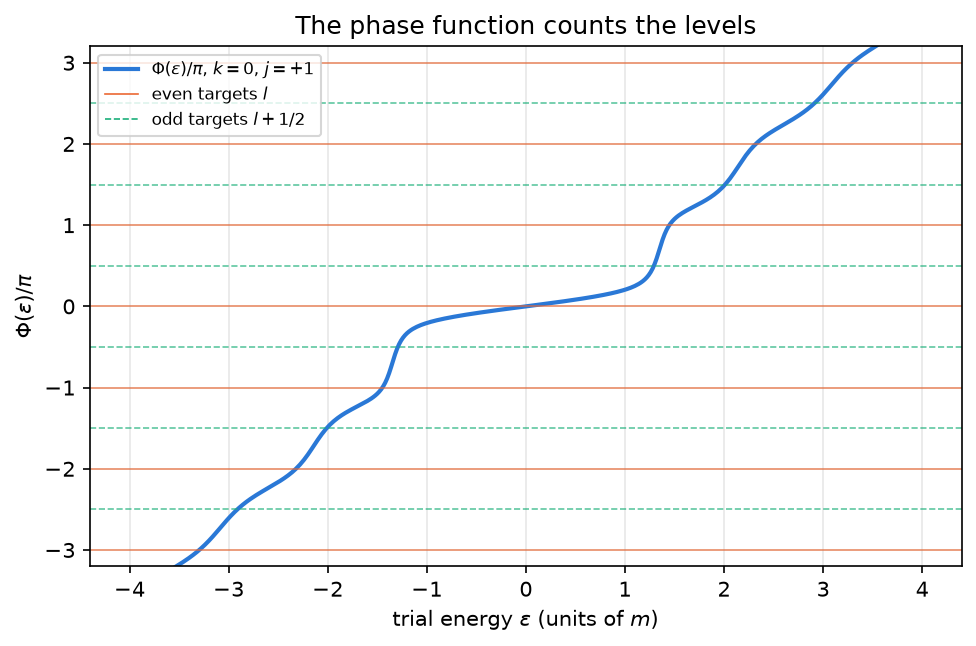

Figure 15e.1 saved as Revision/textbook/figures/15e_1_phase_function.png
PASS Phi increases strictly at all 400 steps


In [4]:
energies = np.linspace(-4.0, 4.0, 401)  # 401 trial energies
phase = np.array([shoot(e, 0.0, 1, 0.0, FREE_MASS, FREE_POT)[0] for e in energies])
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(energies, phase / math.pi, color=PALETTE[0], lw=2.0,
        label="$\\Phi(\\varepsilon)/\\pi$, $k = 0$, $j = +1$")
for whole in range(-4, 5):
    ax.axhline(whole, color=PALETTE[1], lw=0.8, alpha=0.7)  # even targets l pi
    ax.axhline(whole + 0.5, color=PALETTE[2], lw=0.8, ls="--", alpha=0.7)  # odd
ax.plot([], [], color=PALETTE[1], lw=0.8, label="even targets $l$")
ax.plot([], [], color=PALETTE[2], lw=0.8, ls="--", label="odd targets $l + 1/2$")
ax.set_xlabel("trial energy $\\varepsilon$ (units of $m$)")
ax.set_ylabel("$\\Phi(\\varepsilon) / \\pi$")
ax.set_title("The phase function counts the levels")
ax.set_ylim(-3.2, 3.2)
ax.legend(fontsize=8, loc="upper left")
save_figure(fig, "phase_function",
            "The phase function $\\Phi(\\varepsilon)/\\pi$ (vertical axis) of the "
            "free block $j = +1$ at $k = 0$ against the trial energy $\\varepsilon$ "
            "(horizontal axis, units of $m$). It rises steadily; it crosses a solid "
            "line (a whole number $l$) at each level of even parity and a dashed "
            "line ($l + 1/2$) at each level of odd parity. The flat part around "
            "$\\varepsilon = 0$ is the gap of the free field, with the zero mode at "
            "$\\Phi = 0$.")
check(bool(np.all(np.diff(phase) > 0.0)), "Phi increases strictly at all 400 steps")

## 8. Finding a level: Newton's method inside a bracket

The next cell finds the level with label $l$: the root of $\Phi(\varepsilon) - t_l$
with the target $t_l = l\pi$ (even) or $\pi/2 + l\pi$ (odd). It is the solver's
`find_level`: from a guess it walks with growing steps until the sign of
$\Phi - t_l$ changes (a bracket), then it takes Newton steps
$\varepsilon \to \varepsilon - (\Phi - t_l)/\Phi'$ and falls back to bisection
whenever a Newton step would leave the bracket or does not halve the error, until the
bracket is shorter than $10^{-13}$.

In [5]:
def target(parity, label):
    """Phi of the level with this label: l pi (even) or pi/2 + l pi (odd)."""
    return label * math.pi + (0.0 if parity == "even" else 0.5 * math.pi)


def find_level(k, j, parity, label, a4, mass, pot, guess, grid=GRID, tol=1e-13):
    """The energy of the level (k, j, parity, label) in the potentials mass, pot."""
    t = target(parity, label)
    def g(e):  # Phi - target and its derivative at the energy e
        phi, dphi, _ = shoot(e, k, j, a4, mass, pot, grid)
        return phi - t, dphi
    ec = guess
    gc, dc = g(ec)
    if gc == 0.0:
        return ec
    sign = 1.0 if gc < 0.0 else -1.0  # walk up if Phi is too small, else down
    far = ec
    step = min(max(abs(gc / dc) * 1.2, 1e-4), 2.0)
    while True:  # walk until Phi - t changes sign: then [lo, hi] brackets the root
        e = far + sign * step
        ge, de = g(e)
        if ge * gc <= 0.0:
            lo, hi = (far, e) if sign > 0 else (e, far)
            if abs(ge) < abs(gc):
                ec, gc, dc = e, ge, de
            break
        far, ec, gc, dc = e, e, ge, de
        step *= 2.0
    previous = math.inf
    for _ in range(300):
        if hi - lo <= tol or gc == 0.0:
            break
        new = ec - gc / dc  # the Newton step
        if not lo < new < hi or abs(gc) > 0.5 * previous:
            new = 0.5 * (lo + hi)  # bisection instead
        previous = abs(gc)
        ec = new
        gc, dc = g(ec)
        if gc < 0.0:
            lo = ec
        else:
            hi = ec
    return ec

The next cell computes the exact levels at $k = 0$ (the even ones from the formula,
the odd ones by bisection on $M\sin(pL) + p\cos(pL) = 0$, which is $\tan(pL) = -p/M$
multiplied by $M\cos(pL)$), finds the labels $-3$ to $5$ of both parities by
shooting, and compares. It also compares with the solver's own numerical values in
the record file `spectrum/free-k0-analytic.csv`: the same method on the same grid
must give the same numbers to the root tolerance.

In [6]:
def odd_momentum(n):
    """The n-th root p of M sin(pL) + p cos(pL) = 0, between (n-1/2) pi/L and n pi/L."""
    lo, hi = (n - 0.5) * math.pi / L, n * math.pi / L
    f = lambda p: MASS * math.sin(p * L) + p * math.cos(p * L)
    for _ in range(200):
        mid = 0.5 * (lo + hi)
        lo, hi = (mid, hi) if f(lo) * f(mid) > 0.0 else (lo, mid)
    return 0.5 * (lo + hi)


def exact_level(parity, label):
    """The exact free level at k = 0 with this label (L = 3, M = 1)."""
    if parity == "even":
        n = abs(label)
        return math.copysign(math.sqrt(MASS ** 2 + (n * math.pi / L) ** 2), label) \
            if n else 0.0
    n = label + 1 if label >= 0 else -label  # labels 0, 1, ... and -1, -2, ...
    return math.copysign(math.sqrt(MASS ** 2 + odd_momentum(n) ** 2), label + 0.5)


RECORD_FREE = "Revision/kohn_sham/results/spectrum/free-k0-analytic.csv"
recorded = {}
for line in repository_file(RECORD_FREE).read_text(encoding="utf-8").split("\n")[1:]:
    if line:
        m_, l_, parity, label, eps_num, eps_exact, _ = line.split(",")
        if float(m_) == 1.0 and float(l_) == 3.0:
            recorded[(parity, int(label))] = (float(eps_num), float(eps_exact))
worst_exact, worst_record = 0.0, 0.0
say("parity label   shooting           exact              difference")
for parity in ("even", "odd"):
    for label in range(-3, 6):
        exact = exact_level(parity, label)
        found = find_level(0.0, 1, parity, label, 0.0, FREE_MASS, FREE_POT, exact + 0.01)
        say(f"{parity:5} {label:3d}  {found:17.13f}  {exact:17.13f}"
            f"  {found - exact:10.2e}")
        if abs(exact) < 4.0:
            worst_exact = max(worst_exact, abs(found - exact))
        if (parity, label) in recorded:
            worst_record = max(worst_record, abs(found - recorded[(parity, label)][0]))
report("largest |shooting - exact| for |eps| < 4", f"{worst_exact:.2e}")
report("largest |this notebook - solver record|", f"{worst_record:.2e}")
check(worst_exact < 5e-9, "the shooting levels equal the exact levels within 5e-9",
      record="Revision/kohn_sham/reports/ks-rust-solver.json, check "
             "free_k0_analytic_spectra")
check(worst_record < 1e-12, "the levels equal the solver's levels within 1e-12",
      record=f"{RECORD_FREE}, column eps_numeric")

parity label   shooting           exact              difference
even   -3   -3.2969083097756   -3.2969083094756   -3.00e-10
even   -2   -2.3208814801929   -2.3208814801555   -3.74e-11
even   -1   -1.4479719304030   -1.4479719304020   -9.37e-13
even    0   -0.0000000000000    0.0000000000000   -4.90e-18
even    1    1.4479719304030    1.4479719304020    9.37e-13
even    2    2.3208814801929    2.3208814801555    3.74e-11
even    3    3.2969083097755    3.2969083094756    3.00e-10
even    4    4.3065024545248    4.3065024532345    1.29e-09
even    5    5.3306254626636    5.3306254586872    3.98e-09
odd    -3   -2.9119358754966   -2.9119358753543   -1.42e-10
odd    -2   -2.0106285600592   -2.0106285600459   -1.33e-11
odd    -1   -1.2922928280688   -1.2922928280686   -2.01e-13
odd     0    1.2922928280688    1.2922928280686    2.01e-13
odd     1    2.0106285600592    2.0106285600459    1.34e-11
odd     2    2.9119358754966    2.9119358753543    1.42e-10
odd     3    3.8829900333451    3.88

## 9. Orbitals: the values in the middle of the steps, and the normalisation

RK4 gives the orbital at the step ends. The densities (and the potentials) are
needed on the whole fine grid, so the solver fills in each midpoint by **cubic
Hermite interpolation**: with the values $u_0, u_1$ and derivatives $u'_0, u'_1$ at
the two ends of a step of length $h$, the midpoint value is
$\tfrac12(u_0 + u_1) + \tfrac{h}{8}(u'_0 - u'_1)$ (exact for every cubic polynomial;
the derivatives come from the equation itself). Then the orbital is normalised with
Simpson's rule. The next cell defines this and draws three orbitals: the zero mode,
the first even bulk level at $k = 0$, and the brane-band level at $k = 0.5$ (the
shell $n_2 = 4$). The check compares the zero mode with its exact form
$a = \sqrt{2M/(1 - e^{-2ML})}\,e^{My}$, $b = 0$.

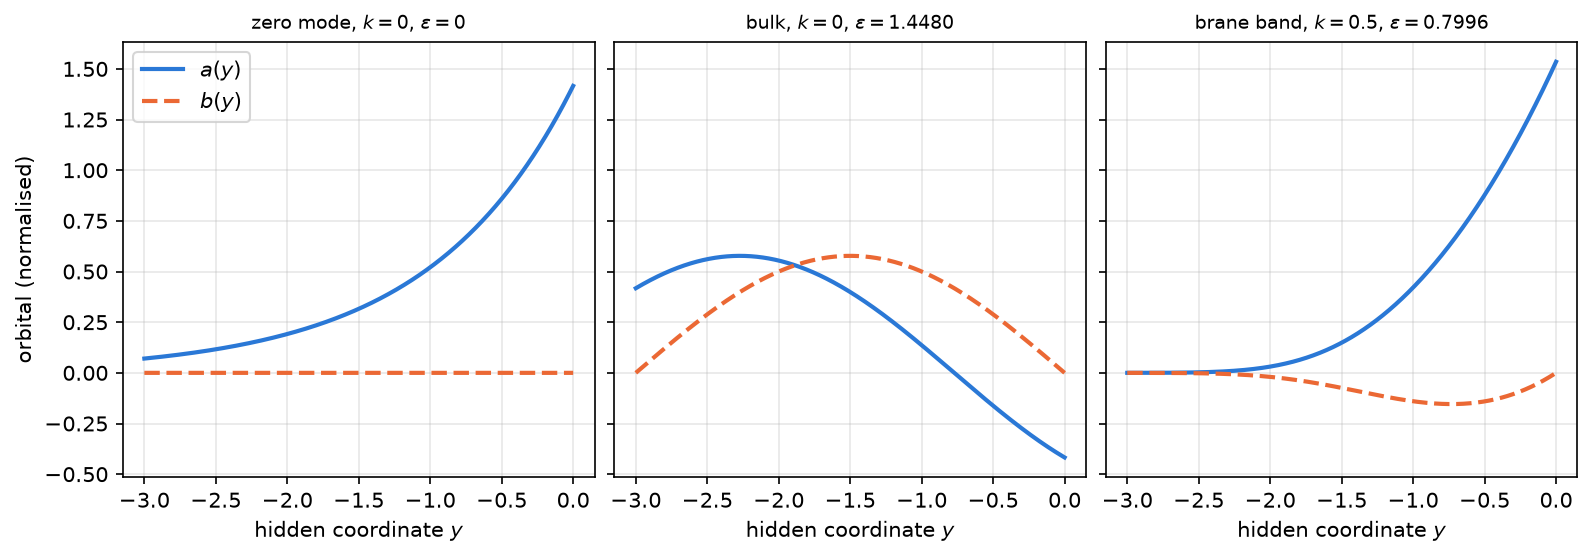

Figure 15e.2 saved as Revision/textbook/figures/15e_2_orbitals.png
RESULT largest deviation of the zero mode from its exact form = 1.35e-12
PASS the zero mode is (e^{My}, 0), normalised, to 1e-11
     reproduces Revision/kohn_sham/reports/ks-rust-solver.json, check
    free_zero_mode_exact


In [7]:
def orbital(eps, k, j, a4, mass, pot, grid=GRID):
    """The normalised orbital (a, b) on the fine grid (two numpy arrays)."""
    _, _, nodes = shoot(eps, k, j, a4, mass, pot, grid, store=True)
    h = grid["h"]
    kk = k * math.exp(-a4)
    a = np.zeros(grid["points"])
    b = np.zeros(grid["points"])
    a[0::2] = [p[0] for p in nodes]  # the step ends
    b[0::2] = [p[1] for p in nodes]
    f = np.arange(0, grid["points"], 2)  # fine indices of the step ends
    m_y = np.array(mass)[f]
    kap = kk * np.array(grid["ew"])[f]
    je = j * (eps - np.array(pot)[f])
    da = m_y * a[f] - (kap + je) * b[f]  # derivatives from the equation
    db = (je - kap) * a[f] - m_y * b[f]
    a[1::2] = 0.5 * (a[f][:-1] + a[f][1:]) + h / 8.0 * (da[:-1] - da[1:])
    b[1::2] = 0.5 * (b[f][:-1] + b[f][1:]) + h / 8.0 * (db[:-1] - db[1:])
    norm = math.sqrt(float(np.sum(grid["simpson"] * (a * a + b * b))))
    return a / norm, b / norm


zero_a, zero_b = orbital(0.0, 0.0, 1, 0.0, FREE_MASS, FREE_POT)
bulk_eps = find_level(0.0, 1, "even", 1, 0.0, FREE_MASS, FREE_POT, 1.4)
bulk_a, bulk_b = orbital(bulk_eps, 0.0, 1, 0.0, FREE_MASS, FREE_POT)
band_eps = find_level(0.5, 1, "even", 0, 0.0, FREE_MASS, FREE_POT, 0.8)
band_a, band_b = orbital(band_eps, 0.5, 1, 0.0, FREE_MASS, FREE_POT)
fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.6), sharey=True,
                         layout="constrained")
for ax, (a, b, title) in zip(axes, [
        (zero_a, zero_b, "zero mode, $k = 0$, $\\varepsilon = 0$"),
        (bulk_a, bulk_b, f"bulk, $k = 0$, $\\varepsilon = {bulk_eps:.4f}$"),
        (band_a, band_b, f"brane band, $k = 0.5$, $\\varepsilon = {band_eps:.4f}$")]):
    ax.plot(Y, a, color=PALETTE[0], lw=2.0, label="$a(y)$")
    ax.plot(Y, b, color=PALETTE[1], lw=2.0, ls="--", label="$b(y)$")
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("hidden coordinate $y$")
axes[0].set_ylabel("orbital (normalised)")
axes[0].legend()
save_figure(fig, "orbitals",
            "Three normalised orbitals of the free block $j = +1$ (components $a$, "
            "solid, and $b$, dashed; vertical axis, units of $m^{1/2}$) against the "
            "hidden coordinate $y$ (horizontal axis, tip at $-3$, brane at $0$): the "
            "zero mode at $k = 0$, which is $e^{y}$ and sits at the brane; the first "
            "even bulk level at $k = 0$, which fills the whole interval; and the "
            "brane-band level at $k = 0.5$, again bound to the brane. Each satisfies "
            "$b = 0$ at the tip and at the brane.")
exact_zero = math.sqrt(2.0 * MASS / (1.0 - math.exp(-2.0 * MASS * L))) * np.exp(MASS * Y)
zero_error = max(float(np.max(np.abs(zero_a - exact_zero))),
                 float(np.max(np.abs(zero_b))))
report("largest deviation of the zero mode from its exact form", f"{zero_error:.2e}")
check(zero_error < 1e-11, "the zero mode is (e^{My}, 0), normalised, to 1e-11",
      record="Revision/kohn_sham/reports/ks-rust-solver.json, check "
             "free_zero_mode_exact")

## 10. How accurate is RK4? The order 4

The error of RK4 falls like $h^4$: halving the step divides it by $2^4 = 16$. The
next cell finds the even levels with the labels 2 and 3 at $k = 0$ (exact values
$\sqrt{1 + (2\pi/3)^2}$ and $\sqrt{1 + \pi^2}$) on grids of 100, 200, 400 and 800
steps, prints the errors and their ratios, and draws the errors against the step on
logarithmic axes, where $h^4$ is a straight line of slope 4. The solver measured the
ratio 16.00 between its canonical and refined runs (Revision record
ks-rust-determinism.json, check `refined_free_spectra_convergence_order`).

label 2: errors 2.45e-07, 1.53e-08, 9.59e-10, 5.99e-11; ratios 15.98, 16.00, 16.00
label 3: errors 1.96e-06, 1.23e-07, 7.69e-09, 4.81e-10; ratios 15.96, 15.99, 16.00


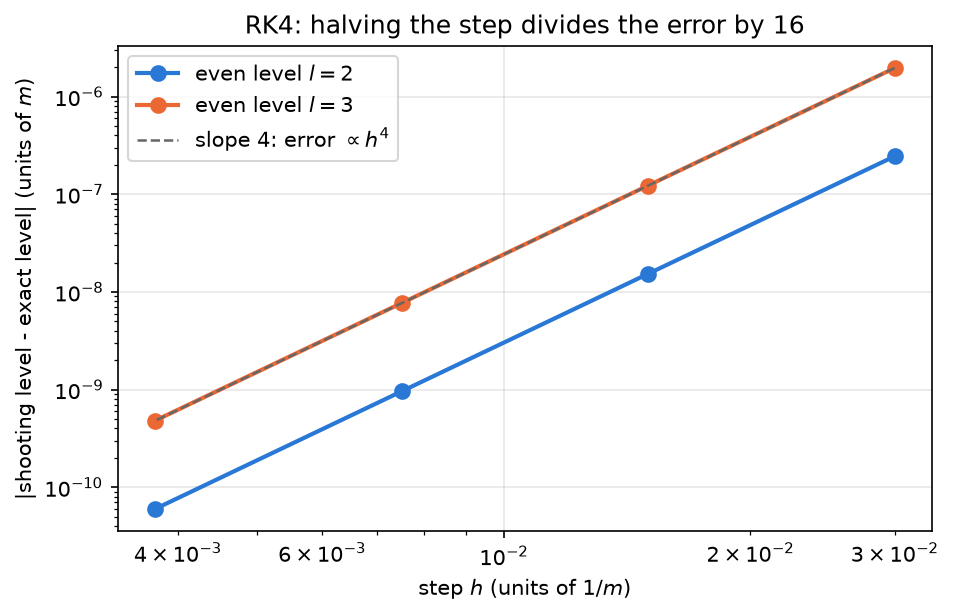

Figure 15e.3 saved as Revision/textbook/figures/15e_3_rk4_convergence.png
RESULT median error ratio for halving the step = 16.00
PASS the error ratio is 16 within 1 (fourth order)
     reproduces Revision/kohn_sham/reports/ks-rust-determinism.json, check
    refined_free_spectra_convergence_order


In [8]:
STEPS = [100, 200, 400, 800]
errors = {2: [], 3: []}
for steps in STEPS:
    grid = make_grid(steps)
    mass = [MASS] * grid["points"]
    pot = [0.0] * grid["points"]
    for label in errors:
        found = find_level(0.0, 1, "even", label, 0.0, mass, pot,
                           exact_level("even", label), grid=grid)
        errors[label].append(abs(found - exact_level("even", label)))
ratios = []
for label, errs in errors.items():
    steps_ratios = [errs[i] / errs[i + 1] for i in range(len(errs) - 1)]
    ratios += steps_ratios
    say(f"label {label}: errors " + ", ".join(f"{e:.2e}" for e in errs)
        + "; ratios " + ", ".join(f"{r:.2f}" for r in steps_ratios))
steps_h = [L / s for s in STEPS]
fig, ax = plt.subplots()
for colour, (label, errs) in zip(PALETTE, errors.items()):
    ax.loglog(steps_h, errs, "o-", color=colour, lw=2.0, ms=7,
              label=f"even level $l = {label}$")
ax.loglog(steps_h, [errors[3][0] * (s / steps_h[0]) ** 4 for s in steps_h], "--",
          color="0.4", lw=1.2, label="slope 4: error $\\propto h^4$")
ax.set_xlabel("step $h$ (units of $1/m$)")
ax.set_ylabel("|shooting level - exact level| (units of $m$)")
ax.set_title("RK4: halving the step divides the error by 16")
ax.legend()
save_figure(fig, "rk4_convergence",
            "Error of two shooting levels (vertical axis, logarithmic, units of $m$) "
            "against the RK4 step $h = 3/G$ for $G = 100$, $200$, $400$, $800$ steps "
            "(horizontal axis, logarithmic): the points lie on lines of slope 4, the "
            "dashed reference, so halving the step divides the error by 16, the "
            "fourth order of the classical Runge-Kutta method.")
middle = sorted(ratios)[len(ratios) // 2]
report("median error ratio for halving the step", f"{middle:.2f}")
check(15.0 < middle < 17.0, "the error ratio is 16 within 1 (fourth order)",
      record="Revision/kohn_sham/reports/ks-rust-determinism.json, check "
             "refined_free_spectra_convergence_order")

## 11. The brane band and the deflating history

For $k > 0$ the lowest even level of $j = +1$ (label 0) is the **brane band**: an
orbital bound to the brane whose energy grows with $k$. The record gives its slope
at $k = 0$ in closed form (Revision/kohn_sham/ks-theory.json, checksNumeric):
$c = \frac{2M}{2M - H}\,\frac{1 - e^{-(2M - H)L}}{1 - e^{-2ML}} = 1.9051482536$ for
$M = H = 1$, $L = 3$, times $e^{-a_{4,0}}$ at the slice $a_{4,0}$. The next cell
computes the band at 41 momenta from 0 to 2 at the slices $a_{4,0} = 0$, $1$, $2$,
and measures the slope at $k = 0$ from $s(k) = \varepsilon(k)/k$ at
$k = 10^{-4}$ and $2 \times 10^{-4}$. Without interaction the band is an **odd**
function of $k$: the two exact symmetries of the block Hamiltonian (Revision record
ks-theory.json, blockEquation.typeRelation), $\sigma_3 h_j(k) \sigma_3 = h_{-j}(-k)$
and $h_{-1} = -h_{+1}$ (for $v = 0$), give together that $-\varepsilon$ is a level
of $h_{+1}(-k)$ whenever $\varepsilon$ is a level of $h_{+1}(k)$. So
$\varepsilon(k) = c k - d k^3 + \dots$ and $s(k) = c - d k^2 + \dots$: the error of
$s$ grows fourfold when $k$ doubles, and the **Richardson extrapolation**
$\tfrac{1}{3}(4 s(k) - s(2k))$ removes it (the $k^2$ terms cancel:
$4(c - dk^2) - (c - 4dk^2) = 3c$). The cell prints the measured factor. Finally it
checks the **rescaling identity**: the level at the slice $a_{4,0}$ equals the
level at the slice $0$ with the momentum $k e^{-a_{4,0}}$, because $a_{4,0}$ enters
only through $\kappa k$.

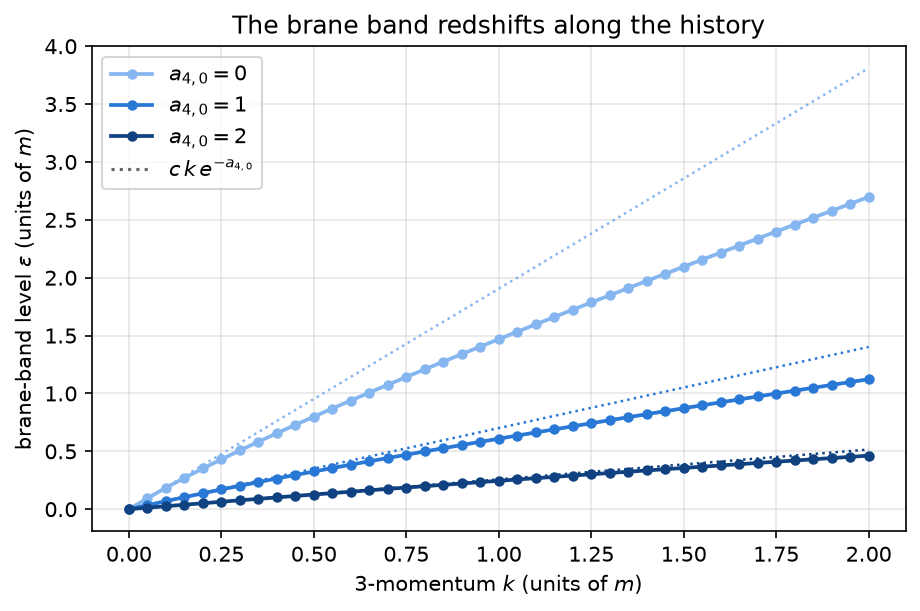

Figure 15e.4 saved as Revision/textbook/figures/15e_4_brane_band.png
RESULT growth of the error of eps(k)/k when k doubles = 4.0000
RESULT slope c times e^{a4,0} at a4,0 = 0, 1, 2 = 1.9051482536, 1.9051482536,
    1.9051482536
RESULT largest violation of the rescaling identity = 0.0e+00
PASS the brane-band slope is c e^{-a4,0} with c = 1.9051482536
     reproduces Revision/kohn_sham/reports/ks-rust-solver.json, check
    free_brane_band_slope
PASS eps(k, a4,0) = eps(k e^{-a4,0}, 0) within 1e-12
     reproduces Revision/kohn_sham/reports/ks-rust-solver.json, check
    free_rescaling_relation_and_band_monotone


In [9]:
THEORY = json.loads(repository_file("Revision/kohn_sham/ks-theory.json").read_text(
    encoding="utf-8"))  # the theory file of the solver
C_RECORD = float(THEORY["checksNumeric"]["braneBandSlope_M1_H1_L3_a0"])
c_formula = (2 * MASS / (2 * MASS - H) * (1 - math.exp(-(2 * MASS - H) * L))
             / (1 - math.exp(-2 * MASS * L)))


def band(k, a4):
    """The brane-band level (j = +1, even, label 0) at momentum k and slice a4."""
    return find_level(k, 1, "even", 0, a4, FREE_MASS, FREE_POT, 1.9 * k * math.exp(-a4))


momenta = np.linspace(0.0, 2.0, 41)
fig, ax = plt.subplots()
slopes = []
for shade, a4 in zip(("#86b6ef", "#2a78d6", "#104281"), (0.0, 1.0, 2.0)):
    curve = [band(k, a4) for k in momenta]
    ax.plot(momenta, curve, "o-", color=shade, ms=4, lw=1.8,
            label=f"$a_{{4,0}} = {a4:.0f}$")
    ax.plot(momenta, c_formula * momenta * math.exp(-a4), ":", color=shade, lw=1.2)
    s1, s2 = band(1e-4, a4) / 1e-4, band(2e-4, a4) / 2e-4  # s(k) and s(2k)
    slopes.append((4.0 * s1 - s2) / 3.0 * math.exp(a4))  # slope times e^{a4,0}
    if a4 == 0.0:
        s4 = band(4e-4, a4) / 4e-4  # s(4k), to measure how the error grows
        growth = (s4 - s2) / (s2 - s1)  # 4 if the error of s is proportional to k^2
ax.plot([], [], ":", color="0.4", label="$c\\,k\\,e^{-a_{4,0}}$")
ax.set_xlabel("3-momentum $k$ (units of $m$)")
ax.set_ylabel("brane-band level $\\varepsilon$ (units of $m$)")
ax.set_title("The brane band redshifts along the history")
ax.legend()
save_figure(fig, "brane_band",
            "The brane-band level $\\varepsilon(k)$ (vertical axis, units of $m$) "
            "against the 3-momentum $k$ (horizontal axis, units of $m$) at the "
            "slices $a_{4,0} = 0$, $1$, $2$ (light to dark blue); the dotted lines "
            "are the tangents $c\\,k\\,e^{-a_{4,0}}$ at $k = 0$ with "
            "$c = 1.9051482536$. Along the deflating history the whole band is "
            "squeezed toward $\\varepsilon = 0$: each curve is the previous one with "
            "the momentum axis stretched by $e = 2.718$.")
rescale = max(abs(band(k, a4) - band(k * math.exp(-a4), 0.0))
              for k in (0.25, 1.0, 2.5) for a4 in (0.5, 1.0, 2.0))
report("growth of the error of eps(k)/k when k doubles", f"{growth:.4f}")
report("slope c times e^{a4,0} at a4,0 = 0, 1, 2",
       ", ".join(f"{s:.10f}" for s in slopes))
report("largest violation of the rescaling identity", f"{rescale:.1e}")
check(abs(c_formula - C_RECORD) < 1e-14 and
      max(abs(s - C_RECORD) for s in slopes) < 1e-9 * C_RECORD,
      "the brane-band slope is c e^{-a4,0} with c = 1.9051482536",
      record="Revision/kohn_sham/reports/ks-rust-solver.json, check "
             "free_brane_band_slope")
check(rescale < 1e-12, "eps(k, a4,0) = eps(k e^{-a4,0}, 0) within 1e-12",
      record="Revision/kohn_sham/reports/ks-rust-solver.json, check "
             "free_rescaling_relation_and_band_monotone")

## 12. The self-consistent loop for N = 8

Now the interaction. The eight particles of the state $N = 8$ fill the zero modes of
both block types $j = \pm 1$ at $k = 0$ (four orbitals each). The next cell defines
one **iteration**: from the current potentials ($M - m$ and $v$ on the fine grid,
one vector `x` of length $2 \times 1801$) it finds the two occupied levels
(label 0, even parity, $k = 0$, $j = \pm 1$), builds their normalised orbitals, the
proper densities $n$ and $S$, the output potentials, the residual (largest
difference between output and input) and the energy $E_{KS}$. It also defines
**Anderson mixing** exactly as the solver does: it keeps the last six inputs $x_i$
and residuals $r_i$, finds the weights $c_i$ with $\sum c_i = 1$ that make
$\sum c_i r_i$ as small as possible (a small linear system), and takes
$\sum c_i (x_i + \beta r_i)$ with $\beta = 0.4$ as the next input; its history is
cleared when a residual grows tenfold.

In [10]:
POINTS = GRID["points"]
P_FACTOR = 1.0 / (E6 * VOL7)  # P = e^{-6Hy}/Vol_7 on the fine grid


def iteration(x, lam, a4, guesses):
    """One Kohn-Sham iteration for N = 8; returns (residual, x_out, E, levels)."""
    mass = (MASS + x[:POINTS]).tolist()
    pot = x[POINTS:].tolist()
    n = np.zeros(POINTS)
    s = np.zeros(POINTS)
    levels = {}
    for j in (1, -1):  # the two block types, each level four-fold (g = 4)
        eps = find_level(0.0, j, "even", 0, a4, mass, pot, guesses.get(j, 0.0))
        a, b = orbital(eps, 0.0, j, a4, mass, pot)
        weight = 0.5 * 4.0 * 1.0  # w g f with w = 1/2 (the Z2 doubling)
        n += weight * P_FACTOR * (a * a + b * b)
        s += weight * P_FACTOR * j * 2.0 * a * b
        levels[j] = eps
    x_out = np.concatenate([lam * (15.0 / 16.0) * s, lam * (-1.0 / 16.0) * n])
    e_int = lam * (15.0 / 32.0 * s * s - 1.0 / 32.0 * n * n)
    energy = sum(4.0 * e for e in levels.values()) \
        - 2.0 * VOL7 * float(np.sum(GRID["simpson"] * E6 * e_int))
    return float(np.max(np.abs(x_out - x))), x_out, energy, levels


class Anderson:
    """Anderson (Pulay) mixing with the solver's depth 6 and beta 0.4."""

    def __init__(self, depth=6, beta=0.4):
        self.depth, self.beta = depth, beta
        self.xs, self.rs, self.best = [], [], math.inf

    def next(self, x, r):
        size = float(np.max(np.abs(r)))
        if size > 10.0 * self.best and self.xs:
            self.xs, self.rs = [], []  # the residual grew tenfold: start again
        self.best = min(self.best, size)
        self.xs = (self.xs + [x.copy()])[-self.depth:]
        self.rs = (self.rs + [r.copy()])[-self.depth:]
        count = len(self.xs)
        # minimise |sum c_i r_i|^2 with sum c_i = 1 (a Lagrange multiplier):
        system = np.zeros((count + 1, count + 1))
        gram = np.array([[float(np.dot(u, v)) for v in self.rs] for u in self.rs])
        system[:count, :count] = gram + 1e-12 * np.max(np.diag(gram)) * np.eye(count)
        system[:count, count] = 1.0
        system[count, :count] = 1.0
        right = np.zeros(count + 1)
        right[count] = 1.0
        weights = np.linalg.solve(system, right)[:count]
        return sum(c * (xi + self.beta * ri)
                   for c, xi, ri in zip(weights, self.xs, self.rs))


def solve_n8(lam, a4=0.0, mixing="anderson", tol=1e-11, limit=200):
    """The self-consistent N = 8 state: (E, levels, iteration history, x)."""
    x = np.zeros(2 * POINTS)
    mixer = Anderson()
    guesses, history = {}, []
    for it in range(1, limit + 1):
        residual, x_out, energy, levels = iteration(x, lam, a4, guesses)
        guesses = levels
        history.append((it, residual, energy))
        if residual <= tol:
            return energy, levels, history, x
        r = x_out - x
        x = mixer.next(x, r) if mixing == "anderson" else x + 0.4 * r
    raise RuntimeError("no convergence")

The next cell reads the coupling $\lambda_1$ of $N = 8$ from the record
(`parameters.json`), runs the loop with Anderson mixing, prints the residual and the
energy of every iteration, and compares with the record: the energy $E_{KS}$ and the
occupied level (the HOMO) of the state `N8_lamp1_a00` in `ground/summary.csv`, and
the residuals of the first six iterations recorded in `ground/runs.json` (from the
seventh iteration on, the residuals are differences of nearly equal numbers and
depend on the last digits of the arithmetic, which Python and Rust do in a
different order, so they are not compared). It checks that both block types give
the same level, as the exact
symmetry $\sigma_3 h_j(k)\sigma_3 = h_{-j}(-k)$ of the block Hamiltonian demands at
$k = 0$.

In [11]:
params = json.loads(repository_file("Revision/kohn_sham/results/parameters.json")
                    .read_text(encoding="utf-8"))
calib = {int(c["N"]): c for c in params["couplingCalibration"]["values"]}
LAM1, LAM2 = calib[8]["lambda1"], calib[8]["lambda2"]
energy, levels, history, x_final = solve_n8(LAM1)
say("iteration   residual        E_KS")
for it, residual, e in history:
    say(f"{it:9d}   {residual:9.3e}   {e:.13e}")
SUMMARY = "Revision/kohn_sham/results/ground/summary.csv"
with open(repository_file(SUMMARY), newline="", encoding="utf-8") as handle:
    ground = {row["id"]: row for row in csv.DictReader(handle)}
runs = {run["id"]: run for run in json.loads(repository_file(
    "Revision/kohn_sham/results/ground/runs.json").read_text(encoding="utf-8"))}
recorded_history = runs["N8_lamp1_a00"]["scfHistory_iteration_residual_E"]
early = max(abs(h[1] - r[1]) / r[1] for h, r in zip(history[:6], recorded_history[:6]))
report("E_KS of N = 8 with lambda_1", f"{energy:.15e}")
report("iterations (this notebook / record)",
       f"{len(history)} / {len(recorded_history)}")
report("largest relative difference of the first six residuals", f"{early:.1e}")
check(abs(energy - float(ground["N8_lamp1_a00"]["E_KS"])) < 1e-15
      and abs(levels[1] - float(ground["N8_lamp1_a00"]["HOMO"])) < 1e-13,
      "E_KS and HOMO of N8_lamp1_a00 reproduced", record=f"{SUMMARY}, row N8_lamp1_a00")
check(early < 1e-5, "the first six residuals equal the recorded ones within 1e-5",
      record="Revision/kohn_sham/results/ground/runs.json, N8_lamp1_a00")
check(abs(levels[1] - levels[-1]) < 1e-13, "the levels of j = +1 and j = -1 are equal")

iteration   residual        E_KS
        1   1.000e-01   9.9151203205334e-04
        2   6.001e-02   1.9758343923358e-04
        3   9.244e-03   -9.3645832230202e-04
        4   1.827e-04   -9.8185433539648e-04
        5   4.731e-05   -9.8609860452246e-04
        6   4.514e-05   -9.8752614355579e-04
        7   1.045e-06   -9.8685650922438e-04
        8   3.423e-08   -9.8684095223338e-04
        9   9.641e-09   -9.8684215930094e-04
       10   1.136e-09   -9.8684263134971e-04
       11   4.471e-11   -9.8684262120157e-04
       12   2.818e-11   -9.8684262031918e-04
       13   7.544e-13   -9.8684261908763e-04
RESULT E_KS of N = 8 with lambda_1 = -9.868426190876337e-04
RESULT iterations (this notebook / record) = 13 / 13
RESULT largest relative difference of the first six residuals = 3.4e-07
PASS E_KS and HOMO of N8_lamp1_a00 reproduced
     reproduces Revision/kohn_sham/results/ground/summary.csv, row N8_lamp1_a00
PASS the first six residuals equal the recorded ones within 1e-5
     rep

## 13. Why Anderson mixing? A comparison with linear mixing

The next cell solves the same state again with **linear mixing** (the next input is
$x + 0.4\,r$) and draws both residual histories together with the solver's recorded
one. Linear mixing reaches the same state but needs several times more iterations;
the solver's record and this notebook's Anderson run lie on top of each other.

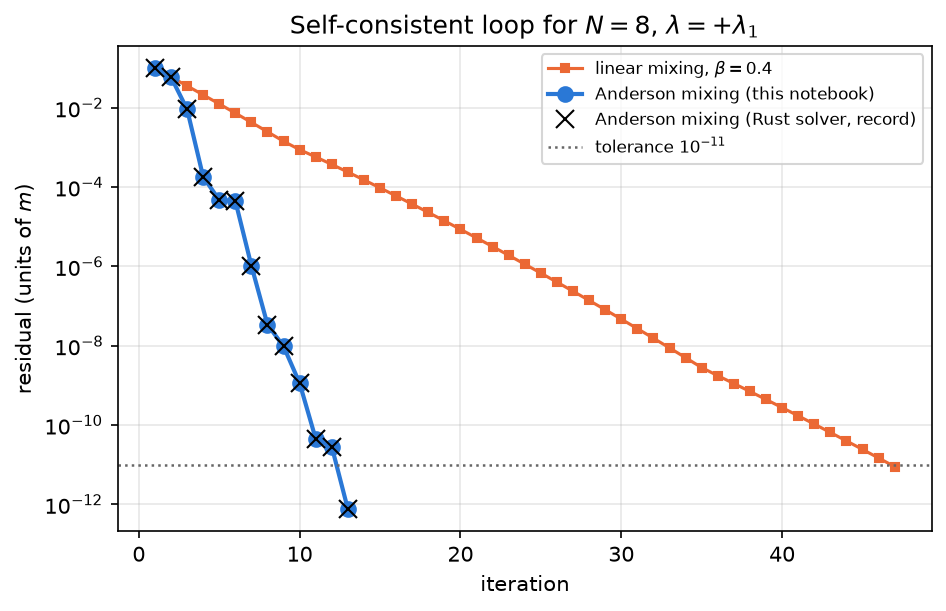

Figure 15e.5 saved as Revision/textbook/figures/15e_5_scf_mixing.png
RESULT iterations: Anderson / linear = 13 / 47
RESULT |E(linear) - E(Anderson)| = 2.1e-13
PASS linear mixing reaches the same energy, with more than twice the iterations


In [12]:
energy_lin, _, history_lin, _ = solve_n8(LAM1, mixing="linear")
fig, ax = plt.subplots()
ax.semilogy([h[0] for h in history_lin], [h[1] for h in history_lin], "s-",
            color=PALETTE[1], ms=4, lw=1.5, label="linear mixing, $\\beta = 0.4$")
ax.semilogy([h[0] for h in history], [h[1] for h in history], "o-",
            color=PALETTE[0], ms=7, lw=2.0, label="Anderson mixing (this notebook)")
ax.semilogy([r[0] for r in recorded_history], [r[1] for r in recorded_history], "x",
            color="black", ms=9, label="Anderson mixing (Rust solver, record)")
ax.axhline(1e-11, color="0.4", ls=":", lw=1.2, label="tolerance $10^{-11}$")
ax.set_xlabel("iteration")
ax.set_ylabel("residual (units of $m$)")
ax.set_title("Self-consistent loop for $N = 8$, $\\lambda = +\\lambda_1$")
ax.legend(fontsize=8)
save_figure(fig, "scf_mixing",
            "Residual of the self-consistent loop (vertical axis, logarithmic, units "
            "of $m$) against the iteration (horizontal axis) for $N = 8$ with the "
            "coupling $+\\lambda_1$: linear mixing (orange squares) needs about "
            "four times as many iterations as Anderson mixing (blue dots); the "
            "crosses are the residuals recorded by the Rust solver, which agree with "
            "this notebook's Anderson run.")
report("iterations: Anderson / linear", f"{len(history)} / {len(history_lin)}")
report("|E(linear) - E(Anderson)|", f"{abs(energy_lin - energy):.1e}")
check(abs(energy_lin - energy) < 1e-12 and len(history_lin) > 2 * len(history),
      "linear mixing reaches the same energy, with more than twice the iterations")

## 14. All four couplings, and an exact symmetry

The next cell solves $N = 8$ for $+\lambda_1$, $-\lambda_1$, $+\lambda_2$,
$-\lambda_2$, compares the energies and occupied levels with the record, and computes
the lowest empty level (the LUMO: the brane band at $k = 0.25$ in the final
potentials) for $+\lambda_1$. Then it checks an **exact symmetry** of this state:
changing the sign of $\lambda$ changes the sign of the energy. The reason: if the
orbital $(a, b)$ of block $j$ solves the problem with $(M, v)$ at $\lambda$, then
$(a, -b)$ (the orbital of the other block type) solves it with $(M, -v)$ and the
level $-\varepsilon$; this flips the sign of $S$, so
$M - m = \tfrac{15}{16}\lambda S$ is unchanged under $\lambda \to -\lambda$, while
$v = -\tfrac{1}{16}\lambda n$ changes sign, exactly as required. The interaction
energy density $e_{int}$ is proportional to $\lambda$ with $n^2$ and $S^2$ unchanged,
so every term of $E_{KS}$ changes sign.

In [13]:
tags = {"lamp1": LAM1, "lamm1": -LAM1, "lamp2": LAM2, "lamm2": -LAM2}
results = {}
worst_e, worst_homo = 0.0, 0.0
for tag, lam in tags.items():
    e, lv, hist, xf = solve_n8(lam)
    results[tag] = (e, lv[1], xf)
    row = ground[f"N8_{tag}_a00"]
    worst_e = max(worst_e, abs(e - float(row["E_KS"])))
    worst_homo = max(worst_homo, abs(lv[1] - float(row["HOMO"])))
    say(f"{tag}: lambda {lam:+.5f}, E_KS {e:+.12e}, HOMO {lv[1]:+.12e},"
        f" {len(hist)} it.")
xf = results["lamp1"][2]
lumo = find_level(0.25, 1, "even", 0, 0.0, (MASS + xf[:POINTS]).tolist(),
                  xf[POINTS:].tolist(), 0.43)
report("LUMO of N8_lamp1_a00 (brane band at k = 0.25)", f"{lumo:.13f}")
antisym = max(abs(results["lamp1"][0] + results["lamm1"][0]),
              abs(results["lamp2"][0] + results["lamm2"][0]))
report("largest |E(+lambda) + E(-lambda)|", f"{antisym:.1e}")
check(worst_e < 1e-15 and worst_homo < 1e-13,
      "E_KS and HOMO of all four couplings reproduced", record=f"{SUMMARY}, rows N8")
check(abs(lumo - float(ground["N8_lamp1_a00"]["LUMO"])) < 1e-12,
      "the LUMO of N8_lamp1_a00 reproduced", record=f"{SUMMARY}, column LUMO")
check(antisym < 1e-17, "E_KS(-lambda) = -E_KS(+lambda) for N = 8")

lamp1: lambda +0.01946, E_KS -9.868426190876e-04, HOMO -2.455627077441e-04, 13 it.
lamm1: lambda -0.01946, E_KS +9.868426190876e-04, HOMO +2.455627077441e-04, 13 it.
lamp2: lambda +0.05838, E_KS -2.862652173608e-03, HOMO -6.910857390418e-04, 17 it.
lamm2: lambda -0.05838, E_KS +2.862652173608e-03, HOMO +6.910857390418e-04, 17 it.
RESULT LUMO of N8_lamp1_a00 (brane band at k = 0.25) = 0.4306983508491
RESULT largest |E(+lambda) + E(-lambda)| = 0.0e+00
PASS E_KS and HOMO of all four couplings reproduced
     reproduces Revision/kohn_sham/results/ground/summary.csv, rows N8
PASS the LUMO of N8_lamp1_a00 reproduced
     reproduces Revision/kohn_sham/results/ground/summary.csv, column LUMO
PASS E_KS(-lambda) = -E_KS(+lambda) for N = 8


## 15. The self-consistent potentials of N = 8

The last figure shows the converged potentials of the four couplings. The potential
$v = -\lambda n/16$ follows the proper density of the zero modes, which grows toward
the tip roughly like $e^{2y}e^{-6y} = e^{-4y}$ (the free orbital is $e^{y}$, the
proper volume $e^{6y}$). The mass shift is smaller: the scalar density $S$ of the
zero modes vanishes without interaction (there $b = 0$) and is created only by the
interaction itself; it also vanishes at the tip, where $b(-L) = 0$.
The check confirms the symmetry of the previous section in the potentials:
$M - m$ is the same and $v$ changes sign under $\lambda \to -\lambda$.

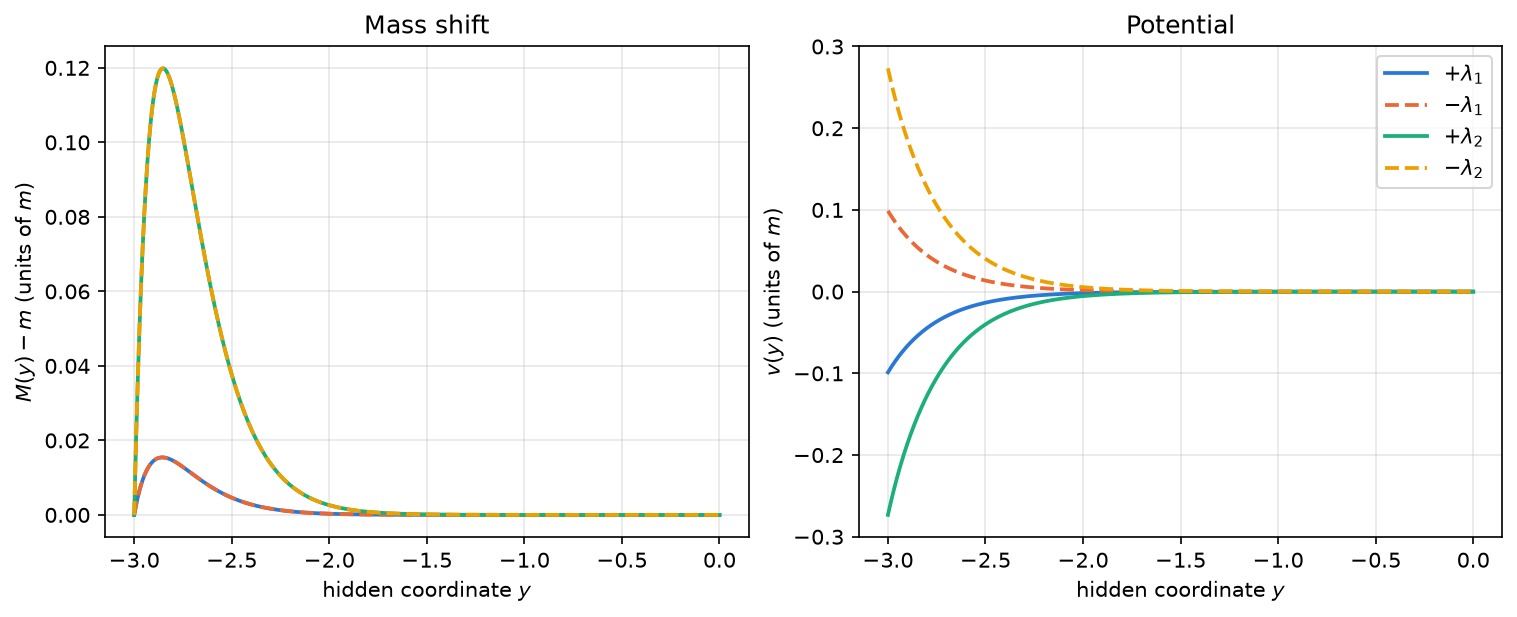

Figure 15e.6 saved as Revision/textbook/figures/15e_6_n8_potentials.png
RESULT largest violation of the potential symmetry = 0.0e+00
PASS M - m is even and v is odd under lambda -> -lambda


In [14]:
fig, (left, right) = plt.subplots(1, 2, figsize=(10.0, 4.0), layout="constrained")
labels = {"lamp1": "$+\\lambda_1$", "lamm1": "$-\\lambda_1$",
          "lamp2": "$+\\lambda_2$", "lamm2": "$-\\lambda_2$"}
for colour, (tag, label) in zip(PALETTE, labels.items()):
    xf = results[tag][2]
    style = "-" if tag.startswith("lamp") else "--"
    left.plot(Y, xf[:POINTS], style, color=colour, lw=1.8, label=label)
    right.plot(Y, xf[POINTS:], style, color=colour, lw=1.8, label=label)
left.set_xlabel("hidden coordinate $y$")
left.set_ylabel("$M(y) - m$ (units of $m$)")
left.set_title("Mass shift")
right.set_xlabel("hidden coordinate $y$")
right.set_ylabel("$v(y)$ (units of $m$)")
right.set_title("Potential")
right.legend()
save_figure(fig, "n8_potentials",
            "The self-consistent mass shift $M(y) - m$ (left) and potential $v(y)$ "
            "(right), vertical axes in units of $m$, of the state $N = 8$ for the "
            "couplings $\\pm\\lambda_1$ and $\\pm\\lambda_2$, against the hidden "
            "coordinate $y$. The potential grows toward the tip roughly like "
            "$e^{-4y}$ and "
            "changes sign with $\\lambda$; the mass shift is smaller and is the same "
            "for $+\\lambda$ and $-\\lambda$ (the dashed curves lie on the solid ones).")
plus, minus = results["lamp1"][2], results["lamm1"][2]  # potentials x of +-lambda_1
mirror = max(float(np.max(np.abs(plus[:POINTS] - minus[:POINTS]))),
             float(np.max(np.abs(plus[POINTS:] + minus[POINTS:]))))
report("largest violation of the potential symmetry", f"{mirror:.1e}")
check(mirror < 1e-14, "M - m is even and v is odd under lambda -> -lambda")

## 16. The last check

The last cell checks that every figure file of this notebook exists and prints the
number of checks that passed.

In [15]:
NAMES = ["phase_function", "orbitals", "rk4_convergence", "brane_band", "scf_mixing",
         "n8_potentials"]
missing = [name for number, name in enumerate(NAMES, start=1)
           if not output_file(f"{FIGURE_FOLDER}/15e_{number}_{name}.png").is_file()]
check(missing == [], "every figure file of this notebook exists")
all_checks_passed()

PASS every figure file of this notebook exists
ALL 18 CHECKS PASSED (notebook 15e)


## 17. What this notebook showed

- The Pruefer angle turns the search for levels into counting: the phase function
  $\Phi(\varepsilon)$ increases strictly, every level is the crossing with one target
  $l\pi$ or $\pi/2 + l\pi$, and no level can be missed (PROVED by the monotonicity
  argument of section 4; COMPUTED here for the free spectrum).
- RK4 shooting on the solver's grid reproduces the exact free levels (within
  $5 \times 10^{-9}$), the solver's own numbers (within $10^{-12}$) and the fourth
  order of the method (error ratio 16).
- The brane band has the slope $c\,e^{-a_{4,0}}$ with $c = 1.9051482536$, and the
  slice enters only through $k e^{-a_{4,0}}$ (the rescaling identity): along the
  deflating history every momentum is redshifted.
- A few dozen lines of Python with Anderson mixing reproduce the interacting $N = 8$
  ground states of the Rust solver: energies, levels and the residuals of the loop.
  Linear mixing converges too, but much more slowly.
- For $N = 8$ the energy is exactly odd in $\lambda$, a symmetry of the zero-mode
  state found and checked here.